In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import text_cleaning as tc
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools
from analysis_utils import *

In [3]:
from tqdm.auto import tqdm
tqdm.pandas()

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [16]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

import matplotlib.ticker as mtick
from matplotlib.ticker import MultipleLocator

# Load Data

In [6]:
data_df = pd.read_pickle('relevant_docs_df.pkl')

In [7]:
data_df.sample(3)

,,lccn,date,year,month,day,edition,sequence,total_tokens,title,jibaro_counts,...,surrounding_text_gibar,word_type,label,relvent_gibar_doc_score,relvent_jibar_doc_score,relevant_jibar_doc,relevant_gibar_doc,relevant_campesin_doc,is_relevant,doc_length
link,text_id,,,,,,,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099747/1897-01-13/ed-1/seq-4/,TB.0049.114,sn91099747,1897-01-13,1897,01,13,ed-1,seq-4,2715,La correspondencia de Puerto Rico,0,...,(),NaN,NaN,0.793521,0.309358,False,False,True,True,468
https://chroniclingamerica.loc.gov/lccn/sn91099739/1896-11-22/ed-1/seq-2/,P2_TB00023,sn91099739,1896-11-22,1896,11,22,ed-1,seq-2,8408,Boletín mercantil de Puerto Rico,3,...,(),NaN,NaN,0.824126,0.283253,False,False,True,True,242
https://chroniclingamerica.loc.gov/lccn/sn91099739/1903-09-22/ed-1/seq-2/,P2_TB00005,sn91099739,1903-09-22,1903,09,22,ed-1,seq-2,3996,Boletín mercantil de Puerto Rico,0,...,(),NaN,NaN,0.788497,0.202847,False,False,True,True,862


In [8]:
def _doc_agg(g):
    jibar_sums = g.loc[g['relevant_jibar_doc']]['contains_search_word_jibar'].sum()
    gibar_sums = g.loc[g['relevant_gibar_doc']]['contains_search_word_gibar'].sum()
    campesin_sums =  g.loc[g['relevant_campesin_doc']]['contains_search_word_campesin'].sum()
    l = g['doc_length'].sum()
    
    return pd.Series({
        'year': g.iloc[0]['year'],
        'title': g.iloc[0]['title'],
        'jibar_freq': jibar_sums / l,
        'gibar_freq': gibar_sums / l,
        'campesin_freq': campesin_sums / l,
        'jibaro_gibaro_freq': (jibar_sums + gibar_sums)/l,
        'contains_jibar': jibar_sums > 0,
        'contains_gibar': gibar_sums > 0,
        'contains_campesin': campesin_sums > 0,
        'contains_jibaro_gibaro': (jibar_sums + gibar_sums) > 0,
        'jibar_sum': jibar_sums,
        'gibar_sum': gibar_sums,
        'campesin_sum': campesin_sums,
        'jibaro_gibaro_sum': jibar_sums + gibar_sums,
        'doc_length': l
    })
        

per_doc_df = (
    data_df
    .reset_index()
    .groupby('link')
    .progress_apply(_doc_agg, include_groups=False)
)

  0%|          | 0/7008 [00:00<?, ?it/s]

In [9]:
per_doc_df.sample(5)

,year,title,jibar_freq,gibar_freq,campesin_freq,jibaro_gibaro_freq,contains_jibar,contains_gibar,contains_campesin,contains_jibaro_gibaro,jibar_sum,gibar_sum,campesin_sum,jibaro_gibaro_sum,doc_length
link,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099747/1894-09-05/ed-1/seq-2/,1894,La correspondencia de Puerto Rico,0.001776,0.0,0.000000,0.001776,True,False,False,True,2,0,0,2,1126
https://chroniclingamerica.loc.gov/lccn/sn91099747/1896-04-21/ed-1/seq-2/,1896,La correspondencia de Puerto Rico,0.000000,0.0,0.001027,0.000000,False,False,True,False,0,0,1,0,974
https://chroniclingamerica.loc.gov/lccn/sn91099747/1903-11-27/ed-1/seq-2/,1903,La correspondencia de Puerto Rico,0.000000,0.0,0.002778,0.000000,False,False,True,False,0,0,1,0,360
https://chroniclingamerica.loc.gov/lccn/sn86077151/1923-06-20/ed-1/seq-12/,1923,El Mundo,0.000000,0.0,0.004003,0.000000,False,False,True,False,0,0,5,0,1249
https://chroniclingamerica.loc.gov/lccn/sn86077151/1920-01-03/ed-1/seq-3/,1920,El Mundo,0.000000,0.0,0.002123,0.000000,False,False,True,False,0,0,1,0,471


In [17]:
per_doc_df.columns

Index(['year', 'title', 'jibar_freq', 'gibar_freq', 'campesin_freq',
       'jibaro_gibaro_freq', 'contains_jibar', 'contains_gibar',
       'contains_campesin', 'contains_jibaro_gibaro', 'jibr_sum', 'gibar_sum',
       'campesin_sum', 'jibaro_gibaro_sum', 'doc_length'],
      dtype='object')

In [10]:
plot_df = (
    per_doc_df
    .reset_index()
    .groupby(['year', 'title'])[['jibar_sum', 'gibar_sum', 'campesin_sum', 'jibaro_gibaro_sum']]
    .sum()
    .reset_index()
)
plot_df.columns = ['year', 'title', 'jibar_mentions', 'gibar_mentions', 'campasin_mentions', 'jibar_gibar_mentions']
plot_df.columns

Index(['year', 'title', 'jibar_mentions', 'gibar_mentions',
       'campasin_mentions', 'jibar_gibar_mentions'],
      dtype='object')

In [40]:
summary_df = plot_df.groupby('title')[['jibar_mentions', 'gibar_mentions', 'campasin_mentions', 'jibar_gibar_mentions']].sum()
summary_df

,jibar_mentions,gibar_mentions,campasin_mentions,jibar_gibar_mentions
title,,,,
Boletín mercantil de Puerto Rico,623,11,1858,634
El Imparcial,263,1,695,264
El Mundo,727,3,1792,730
Gazeta de Puerto-Rico.,25,2,169,27
La correspondencia de Puerto Rico,863,29,2327,892
La democracia,116,5,379,121


In [41]:
summary_df.sum()

jibar_mentions          2617
gibar_mentions            51
campasin_mentions       7220
jibar_gibar_mentions    2668
dtype: int64

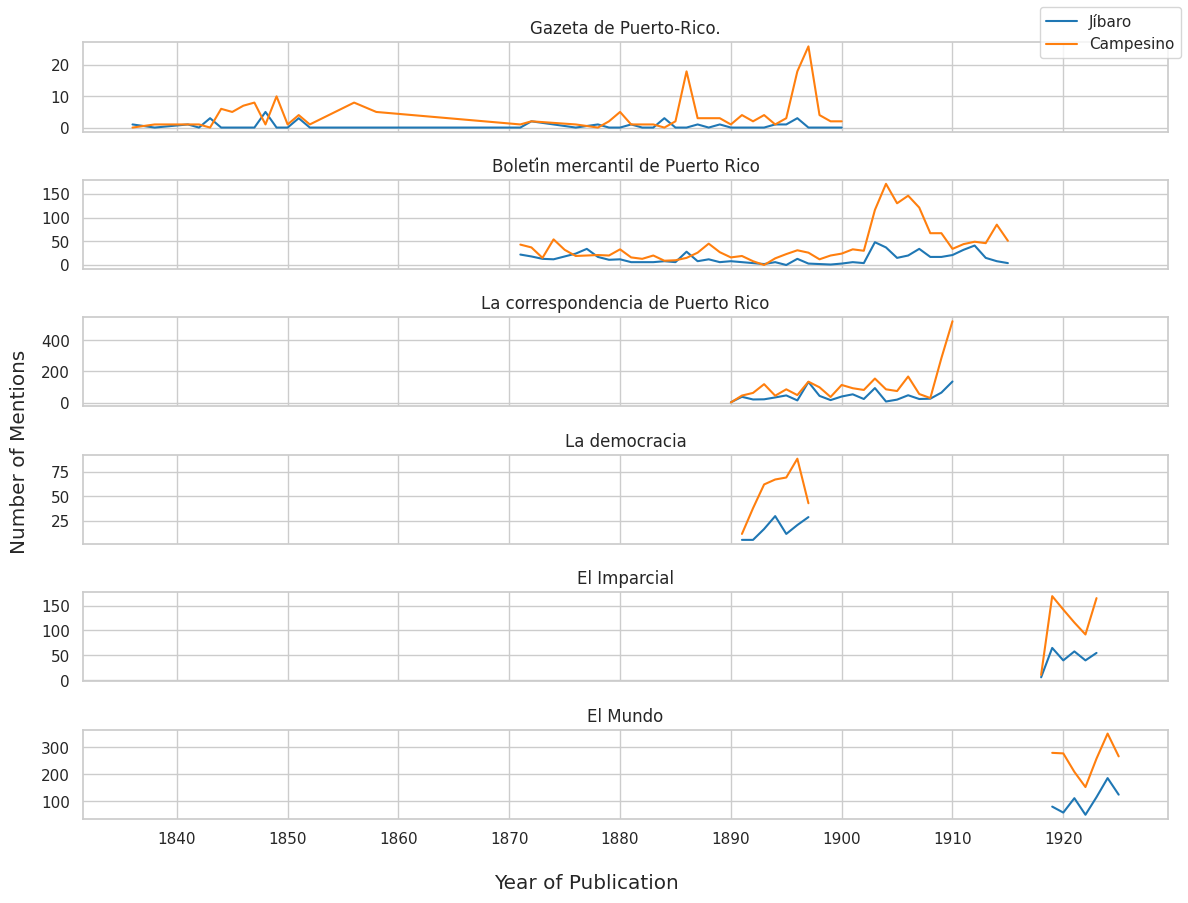

In [21]:
sns.set_theme(style="whitegrid")


plot_df['year'] = pd.to_numeric(plot_df['year'])
freq_colors = {
    'jibar_gibar_mentions': 'tab:blue',
    'campasin_mentions': 'tab:orange',
}
titles = plot_df['title'].unique()
n_titles = len(titles)

fig, axes = plt.subplots(
    n_titles,
    1,
    figsize=(12, 1.5 * n_titles),
    sharex=True
)

for ax, title in zip(axes, titles):
    df_t = plot_df[plot_df['title'] == title]

    ax.plot(
        df_t['year'],
        df_t['jibar_gibar_mentions'],
        color=freq_colors['jibar_gibar_mentions'],
        label='Jíbaro'
    )

    ax.plot(
        df_t['year'],
        df_t['campasin_mentions'],
        color=freq_colors['campasin_mentions'],
        label='Campesino'
    )
    ax.locator_params(axis='y', nbins=4)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_title(title)

fig.supxlabel('Year of Publication')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.supylabel('Number of Mentions')
plt.tight_layout()

plt.show()


In [27]:
dataset_df = pd.read_pickle('prelim_analysis_df.pkl').reset_index()

In [38]:
summary_df = dataset_df.groupby('title')['date'].agg(['count', 'nunique'])
summary_df.columns = ['num_pages', 'num_issues']
summary_df['pages_per_issue'] = summary_df['num_pages']/summary_df['num_issues']
summary_df

,num_pages,num_issues,pages_per_issue
title,,,
Boletín mercantil de Puerto Rico,49955,8581,5.821583
El Imparcial,13273,1464,9.066257
El Mundo,21237,2092,10.151530
Gazeta de Puerto-Rico.,46329,8601,5.386467
La correspondencia de Puerto Rico,26880,6526,4.118909
La democracia,6091,1528,3.986257


In [39]:
summary_df['num_issues'].sum()

np.int64(28792)

In [42]:
dataset_df['total_tokens'].sum()

np.int64(629424801)

# Wordclouds

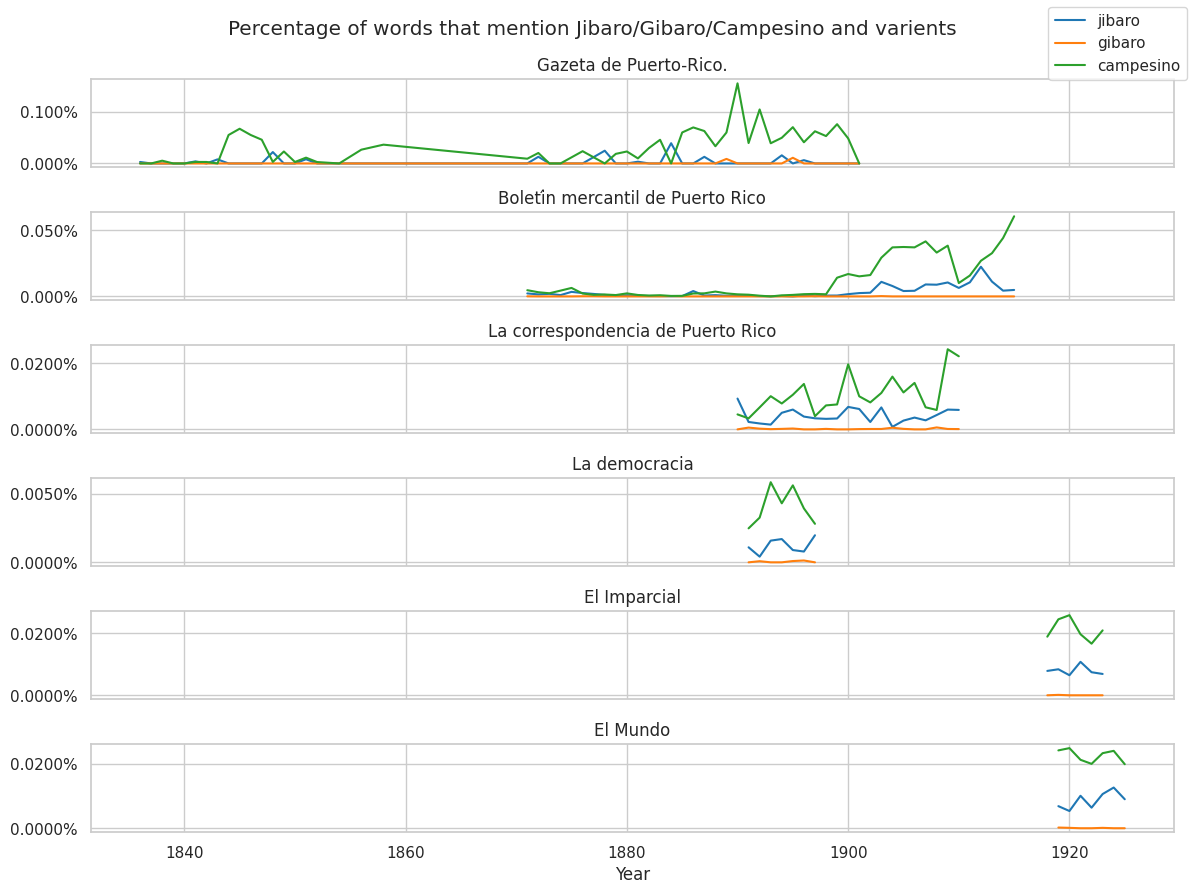

In [40]:
sns.set_theme(style="whitegrid")


plot_df['year'] = pd.to_numeric(plot_df['year'])
freq_colors = {
    'relevant_jibar_doc': 'tab:blue',
    'relevant_gibar_doc': 'tab:orange',
    'relevant_campesin_doc': 'tab:green'
}
titles = plot_df['title'].unique()
n_titles = len(titles)

fig, axes = plt.subplots(
    n_titles,
    1,
    figsize=(12, 1.5 * n_titles),
    sharex=True
)

for ax, title in zip(axes, titles):
    df_t = plot_df[plot_df['title'] == title]

    ax.plot(
        df_t['year'],
        df_t['relevant_jibar_doc'],
        color=freq_colors['relevant_jibar_doc'],
        label='jibaro'
    )

    ax.plot(
        df_t['year'],
        df_t['relevant_gibar_doc'],
        color=freq_colors['relevant_gibar_doc'],
        label='gibaro'
    )

    ax.plot(
        df_t['year'],
        df_t['relevant_campesin_doc'],
        color=freq_colors['relevant_campesin_doc'],
        label='campesino'
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title)
    # ax.set_ylabel("Frequency")

axes[-1].set_xlabel("Year")

# Create one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Percentage of words that mention Jibaro/Gibaro/Campesino and varients")
plt.tight_layout()
plt.show()


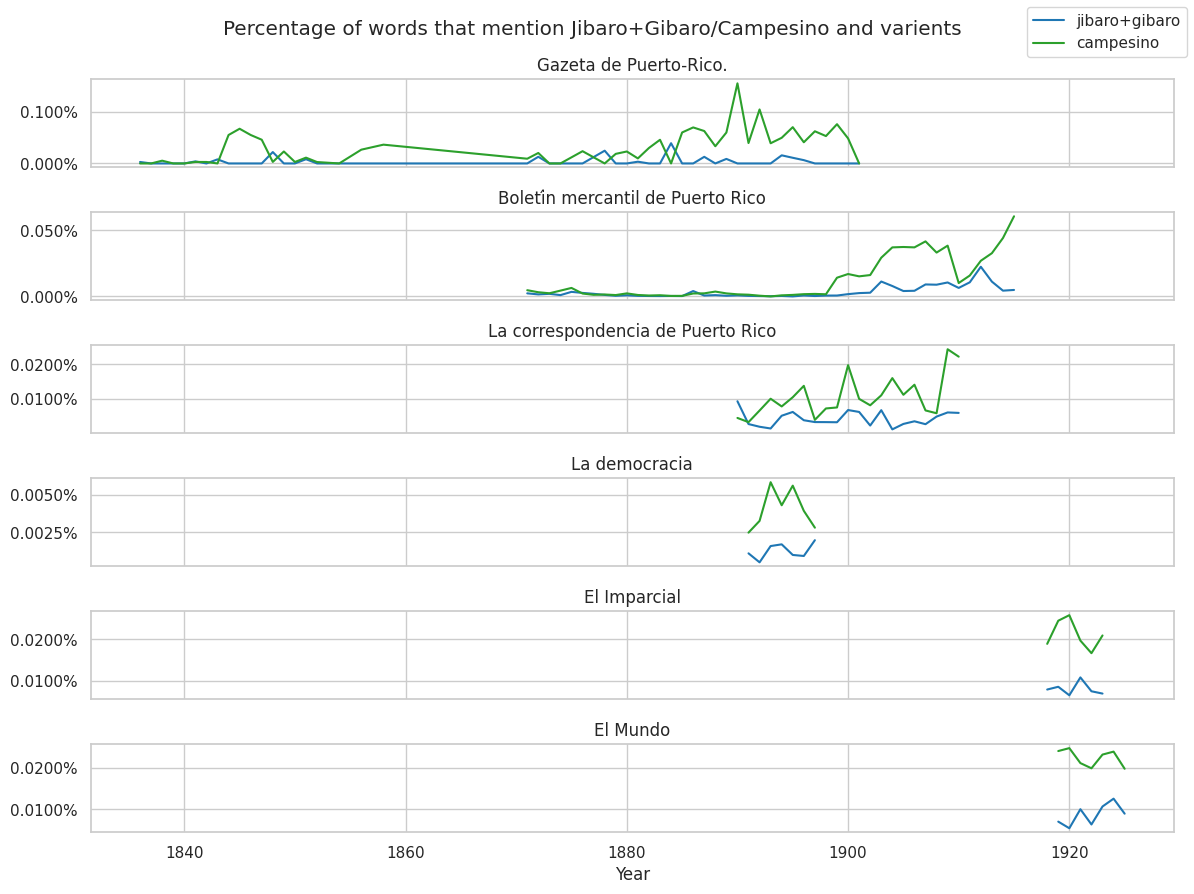

In [41]:
sns.set_theme(style="whitegrid")


plot_df['year'] = pd.to_numeric(plot_df['year'])
freq_colors = {
    'relevant_jibar_gibar_doc': 'tab:blue',
    'relevant_campesin_doc': 'tab:green'
}
titles = plot_df['title'].unique()
n_titles = len(titles)

fig, axes = plt.subplots(
    n_titles,
    1,
    figsize=(12, 1.5 * n_titles),
    sharex=True
)

for ax, title in zip(axes, titles):
    df_t = plot_df[plot_df['title'] == title]

    ax.plot(
        df_t['year'],
        df_t['relevant_jibar_gibar_doc'],
        color=freq_colors['relevant_jibar_gibar_doc'],
        label='jibaro+gibaro'
    )
    ax.plot(
        df_t['year'],
        df_t['relevant_campesin_doc'],
        color=freq_colors['relevant_campesin_doc'],
        label='campesino'
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title)
    # ax.set_ylabel("Frequency")

axes[-1].set_xlabel("Year")

# Create one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Percentage of words that mention Jibaro+Gibaro/Campesino and varients")
plt.tight_layout()
plt.show()


## Word Clouds

In [43]:
from wordcloud import WordCloud

In [44]:
data_df['decade'] = (data_df['year'].astype(int) // 10) * 10

In [77]:
 nlp.Defaults.stop_words

{'a',
 'acuerdo',
 'adelante',
 'ademas',
 'además',
 'afirmó',
 'agregó',
 'ahi',
 'ahora',
 'ahí',
 'al',
 'algo',
 'alguna',
 'algunas',
 'alguno',
 'algunos',
 'algún',
 'alli',
 'allí',
 'alrededor',
 'ambos',
 'ante',
 'anterior',
 'antes',
 'apenas',
 'aproximadamente',
 'aquel',
 'aquella',
 'aquellas',
 'aquello',
 'aquellos',
 'aqui',
 'aquél',
 'aquélla',
 'aquéllas',
 'aquéllos',
 'aquí',
 'arriba',
 'aseguró',
 'asi',
 'así',
 'atras',
 'aun',
 'aunque',
 'añadió',
 'aún',
 'bajo',
 'bastante',
 'bien',
 'breve',
 'buen',
 'buena',
 'buenas',
 'bueno',
 'buenos',
 'cada',
 'casi',
 'cierta',
 'ciertas',
 'cierto',
 'ciertos',
 'cinco',
 'claro',
 'comentó',
 'como',
 'con',
 'conmigo',
 'conocer',
 'conseguimos',
 'conseguir',
 'considera',
 'consideró',
 'consigo',
 'consigue',
 'consiguen',
 'consigues',
 'contigo',
 'contra',
 'creo',
 'cual',
 'cuales',
 'cualquier',
 'cuando',
 'cuanta',
 'cuantas',
 'cuanto',
 'cuantos',
 'cuatro',
 'cuenta',
 'cuál',
 'cuáles',
 'cu

In [51]:
def get_term_freqs(docs, words_to_remove=[]):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        if t in words_to_remove:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [58]:
len(selected_df)

1967

In [60]:
for t in selected_df['surrounding_text_jibar'].sample(20).values:
    print("~~~~~~~~~~~~~~~~~~~~~~~~")
    print(t)

~~~~~~~~~~~~~~~~~~~~~~~~
mandada á hacer por s. m.
el rey don felipe ii, el año de 1582. los
jíbaros, por josé de j. domínguez. el padre
nuestro en caribe del continente. - fray iñigo
~~~~~~~~~~~~~~~~~~~~~~~~
cel & los pobres "jíbaros' que no podían
~~~~~~~~~~~~~~~~~~~~~~~~
aquellas cercanías van mis compatriotas á cortar traviesas, á cortar
maderas preciosas, allí van los pálidos
jíbaros puertorriqueños, infelices! van
entre soldados é indios bravos, á sacar
de las entrañas de 
~~~~~~~~~~~~~~~~~~~~~~~~

será de las primeras en su oíase con que cuente
la isla. la fábrica se denominará el jíbaro.
de juana díaz: el 2g del actual
practicó su visita oficial en esta villi 
~~~~~~~~~~~~~~~~~~~~~~~~
, no
hay que aprenderlas en ningún libro ni
experimentarlas; es algo que el mas torpe
jíbaro lo observa á diario y conoce sobradamente. decirles que cortando la raíz
central ó el pivot á 
~~~~~~~~~~~~~~~~~~~~~~~~
i bién el jíbaro que aprende un poco, quiere y pro i oai 101 myorea contrionyentes co

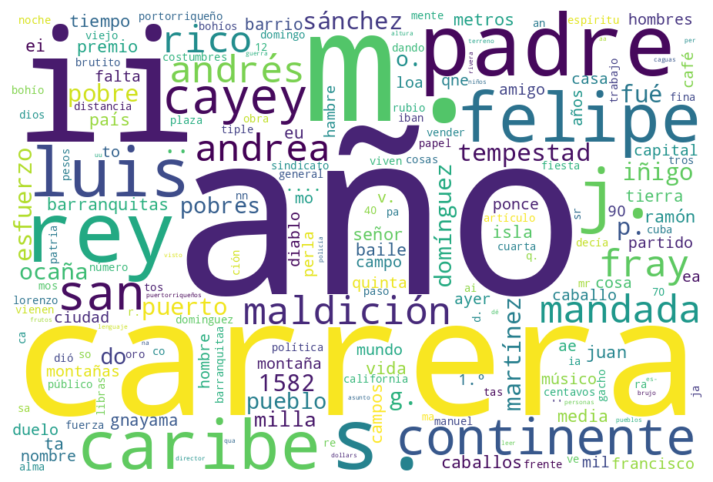

In [59]:
selected_df = data_df.loc[
    (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
    | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
]

tfs = get_term_freqs(selected_df['surrounding_text_jibar'], JIBARO_WORDS + ['don', '...', 'jose', 'josé'])
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

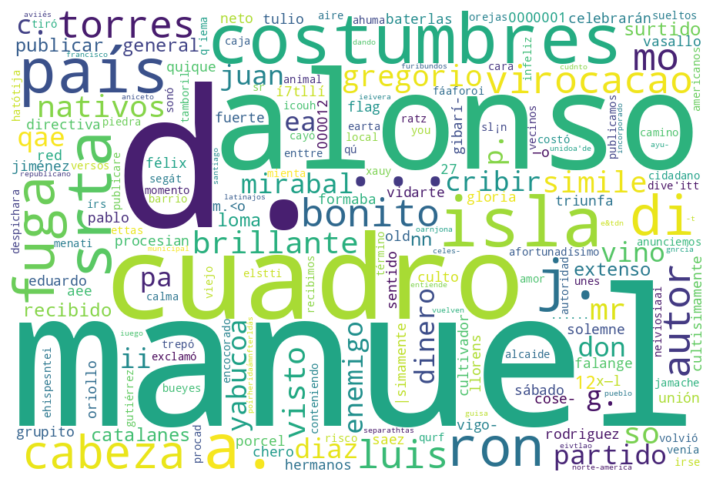

In [61]:
selected_df = data_df.loc[
    (pd.notna(data_df['label']) & (data_df['word_type'] == 'gibar') & (data_df['label'] == 0))
    | (data_df['contains_search_word_gibar'] & (data_df['relvent_gibar_doc_score'] < 0.5))
]

tfs = get_term_freqs(selected_df['surrounding_text_gibar'], GIBARO_WORDS)
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [63]:
data_df['contains_search_word_campesin']

link                                                                       text_id   
https://chroniclingamerica.loc.gov/lccn/sn86077151/1921-05-30/ed-1/seq-1/  P1_TB00001    0
                                                                           P1_TB00002    0
                                                                           P1_TB00010    0
                                                                           P1_TB00011    0
                                                                           P1_TB00012    0
                                                                                        ..
https://chroniclingamerica.loc.gov/lccn/sn90070270/1895-01-23/ed-1/seq-4/  TB.0080.78    0
                                                                           TB.0080.79    0
                                                                           TB.0080.80    0
                                                                           TB.0080.81    0
    

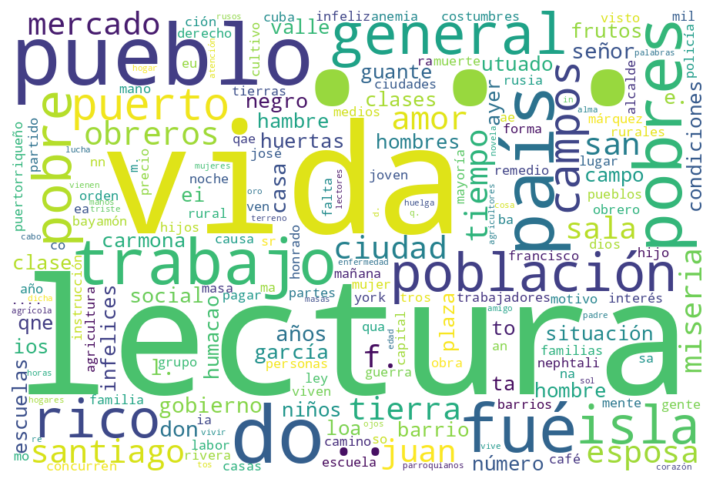

In [67]:
selected_df = data_df.loc[
    data_df['contains_search_word_campesin'] > 0
]

tfs = get_term_freqs(selected_df['surrounding_text_campesino'], CAMPESINO_WORDS)
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

Generating word cloud for decade: (1840, 'tf')


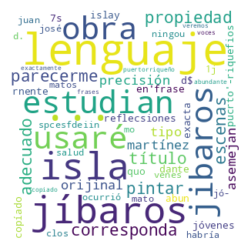

Generating word cloud for decade: (1850, 'tf')


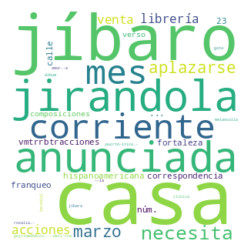

Generating word cloud for decade: (1860, 'tf')


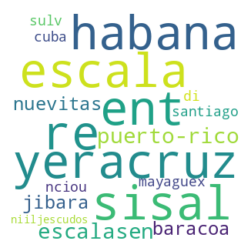

Generating word cloud for decade: (1870, 'tf')


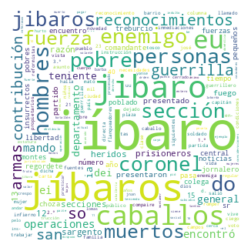

Generating word cloud for decade: (1880, 'tf')


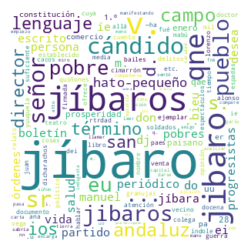

Generating word cloud for decade: (1890, 'tf')


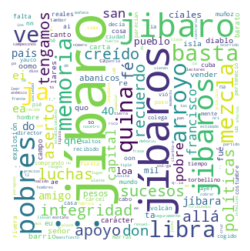

Generating word cloud for decade: (1900, 'tf')


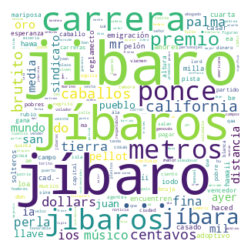

Generating word cloud for decade: (1910, 'tf')


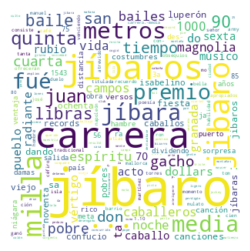

Generating word cloud for decade: (1920, 'tf')


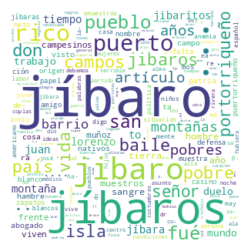

In [143]:
width = 300
height = 300
for i, row in t.iterrows():
    print(f"Generating word cloud for decade: {i}")
    wc = WordCloud(
        width=width,height=height,
        background_color='white'
    )
    wc.generate_from_frequencies(row['surrounding_text_jibar'])
    plt.figure(figsize=(width/100, height/100))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [75]:
import math
import matplotlib.pyplot as plt
from wordcloud import WordCloud

width = 600
height = 600
n_cols = 4
n_items = len(t)

In [73]:
# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
# ]
# t = selected_df.groupby('decade')['surrounding_text_jibar'].apply(get_term_freqs).to_frame()

# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'gibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_gibar'] & (data_df['relvent_gibar_doc_score'] < 0.5))
# ]
# t = selected_df.groupby('decade')['surrounding_text_gibar'].apply(get_term_freqs).to_frame()

selected_df = data_df.loc[
    data_df['contains_search_word_campesin'] > 0
]
t = selected_df.groupby('decade')['surrounding_text_campesino'].apply(lambda x: get_term_freqs(x, CAMPESINO_WORDS)).to_frame()

t.columns = ['surrounding_text']

Generating word cloud for decade: (1830, 'tf')
Generating word cloud for decade: (1840, 'tf')
Generating word cloud for decade: (1850, 'tf')
Generating word cloud for decade: (1870, 'tf')
Generating word cloud for decade: (1880, 'tf')
Generating word cloud for decade: (1890, 'tf')
Generating word cloud for decade: (1900, 'tf')
Generating word cloud for decade: (1910, 'tf')
Generating word cloud for decade: (1920, 'tf')


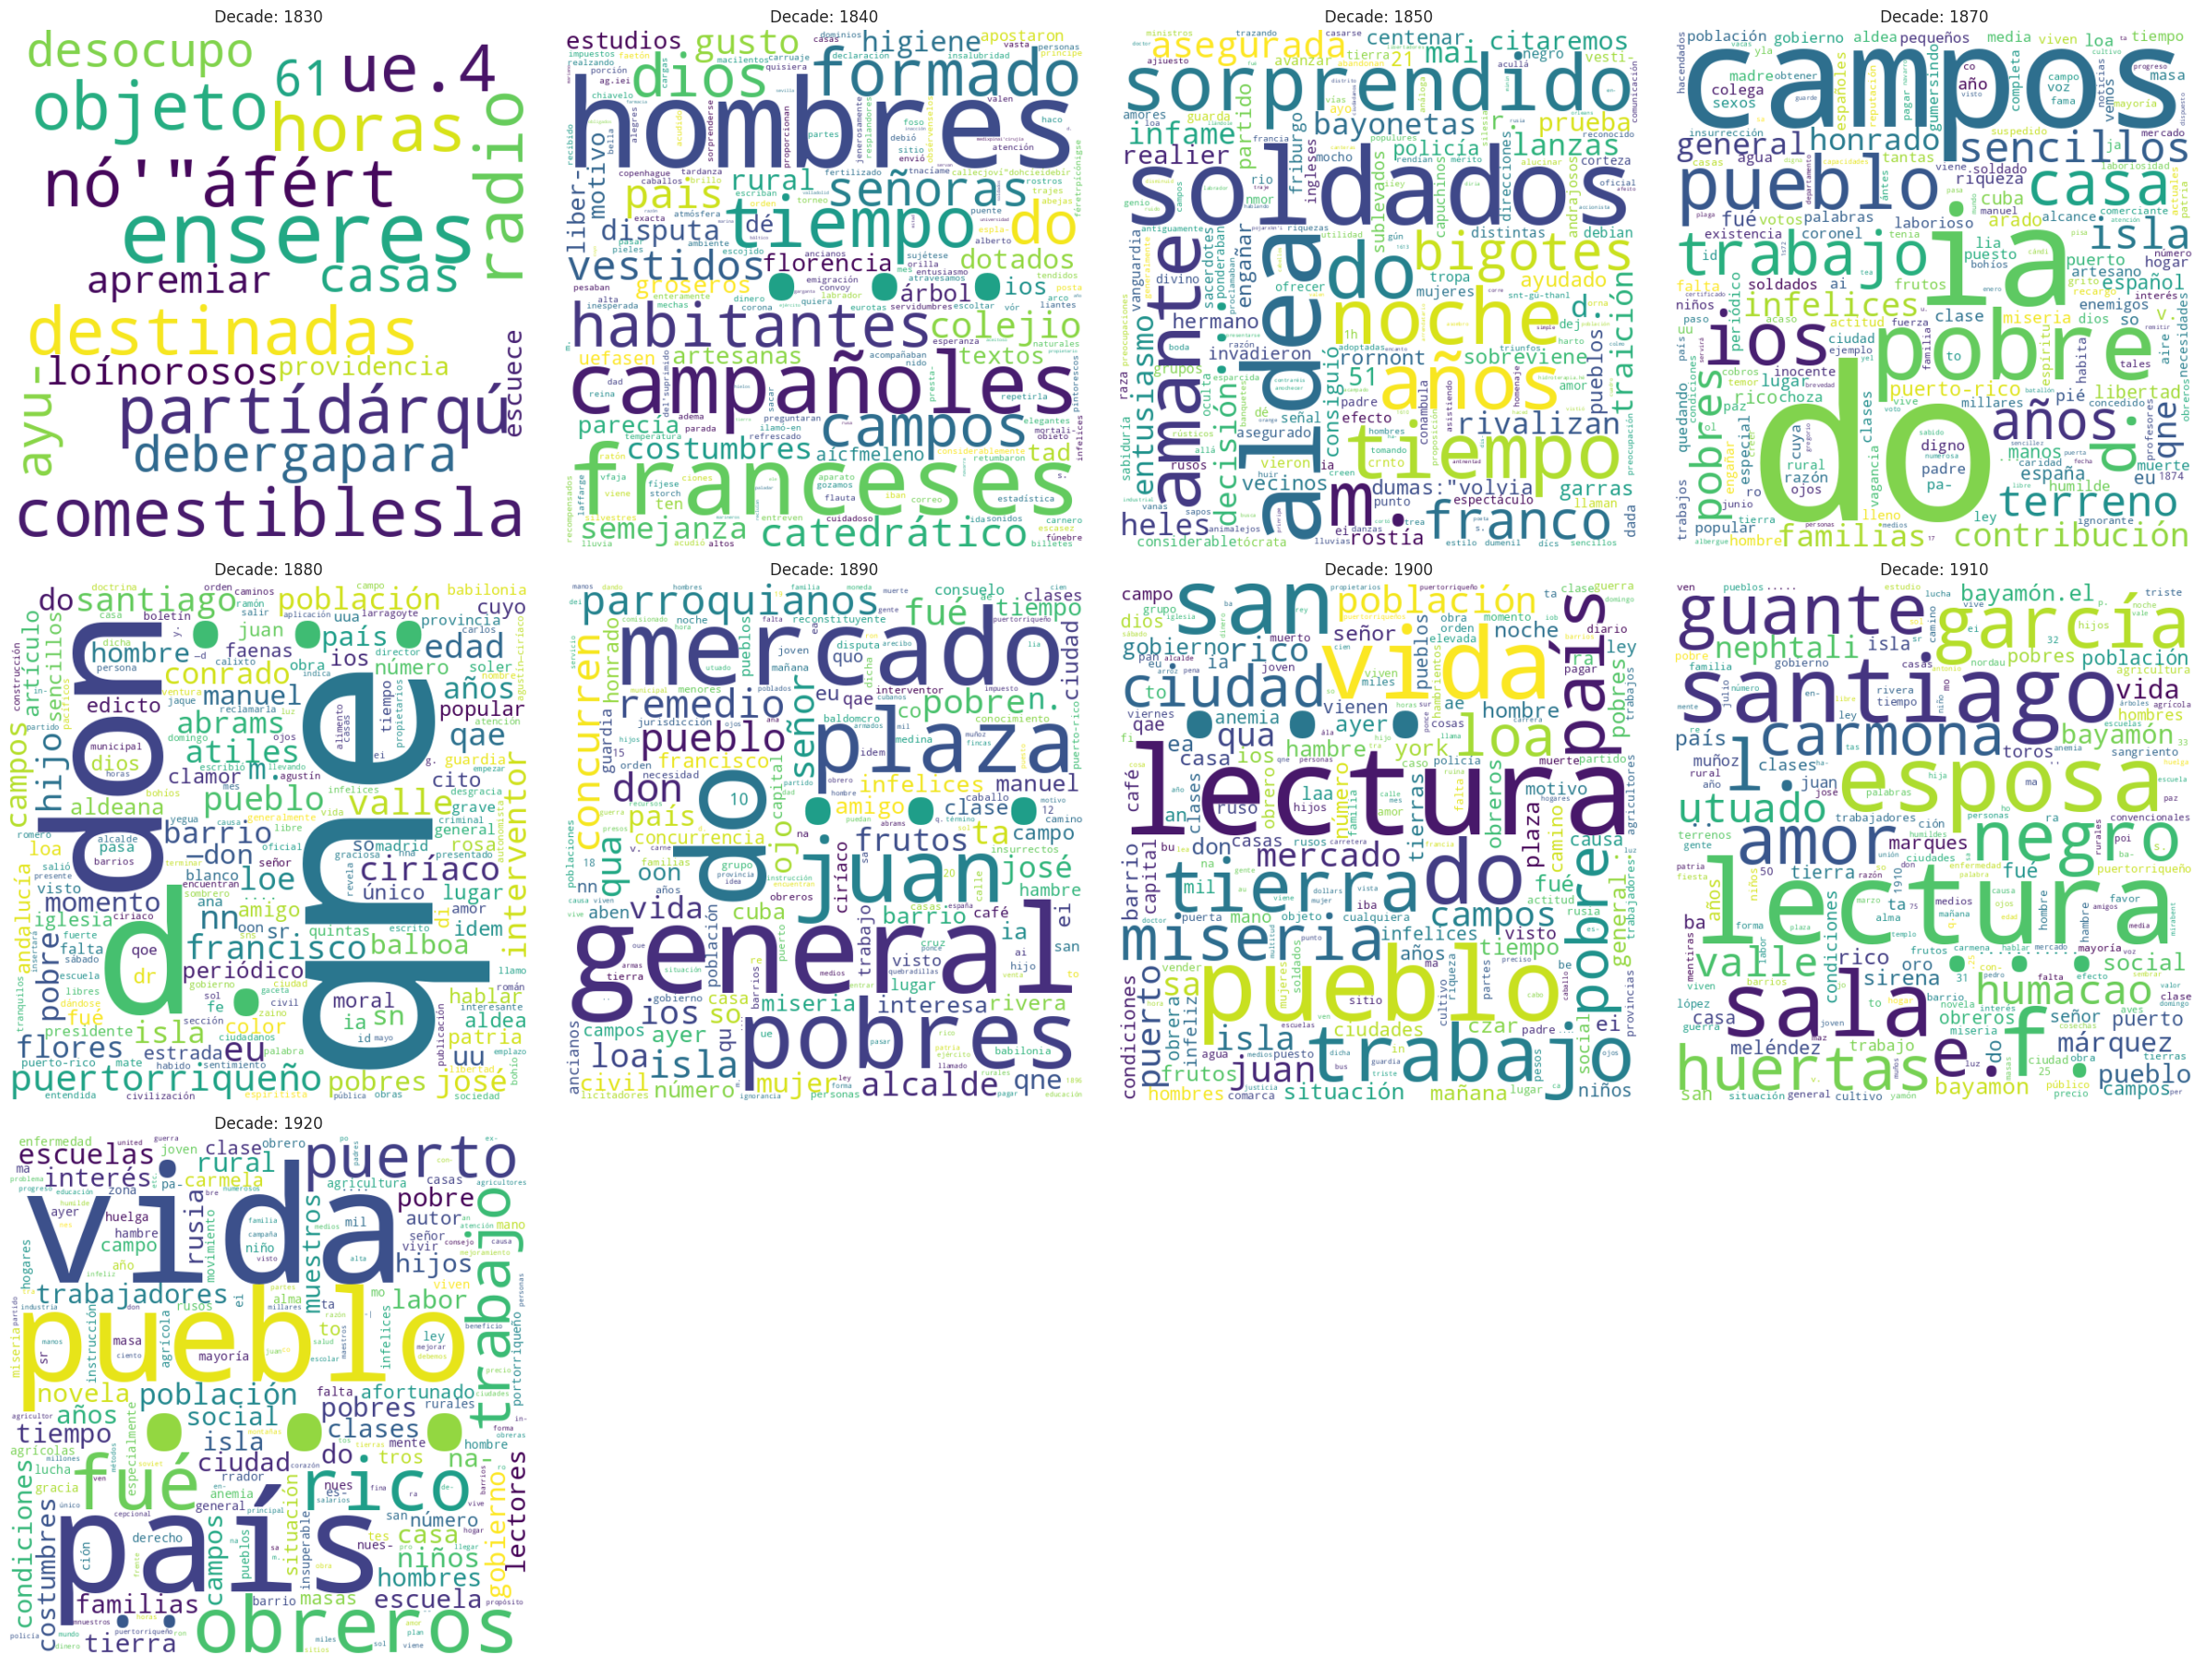

In [76]:
n_cols = 4
n_items = len(t)

n_rows = math.ceil(n_items / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * width / 100, n_rows * height / 100)
)

# If there's only one row, axes won't be 2D — normalize it
axes = axes.flatten()

for ax, (i, row) in zip(axes, t.iterrows()):
    print(f"Generating word cloud for decade: {i}")

    wc = WordCloud(
        width=width,
        height=height,
        background_color="white"
    ).generate_from_frequencies(row["surrounding_text"])

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Decade: {i[0]}")
    ax.axis("off")
    # ax.set_frame_on(True)
    # # 🔲 add black border
    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    #     spine.set_edgecolor("black")
    #     spine.set_linewidth(1.5)
        
# Turn off any leftover empty subplots
for ax in axes[n_items:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [153]:
i

(1920, 'tf')

In [84]:
# selected_df = data_df.loc[data_df['relevant_jibar_doc']]
selected_df = data_df.loc[
    (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
    | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
]
tfs = get_term_freqs(selected_df['surrounding_text_jibar'])
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('jíbaro', 1064),
 ('jíbaros', 542),
 ('jibaro', 396),
 ('...', 282),
 ('jibaros', 128),
 ('carrera', 122),
 ('pobres', 88),
 ('san', 83),
 ('jíbara', 82),
 ('pobre', 76),
 ('fué', 75),
 ('don', 74),
 ('pueblo', 69),
 ('rico', 61),
 ('puerto', 57),
 ('milla', 57),
 ('do', 53),
 ('metros', 53),
 ('país', 50),
 ('vida', 49),
 ('media', 48),
 ('ja', 47),
 ('señor', 47),
 ('isla', 46),
 ('premio', 46),
 ('baile', 45),
 ('juan', 44),
 ('caballos', 43),
 ('..', 42),
 ('campos', 41),
 ('ve', 40),
 ('allá', 39),
 ('tiempo', 39),
 ('recuerdo', 36),
 ('barrio', 36),
 ('libra', 34),
 ('campo', 34),
 ('mezcla', 33),
 ('basta', 33),
 ('ei', 33),
 ('ta', 33),
 ('tierra', 33),
 ('mil', 33),
 ('fé', 32),
 ('arroyo', 32),
 ('mundo', 32),
 ('memoria', 31),
 ('eu', 31),
 ('quina', 30),
 ('integridad', 30),
 ('luchas', 30),
 ('tengamos', 30),
 ('qne', 30),
 ('ea', 30),
 ('capital', 30),
 ('creído', 29),
 ('políticas', 29),
 ('aserto', 29),
 ('apoyo', 29),
 ('sucesos', 29),
 ('amigo', 29),
 ('años', 28),


In [96]:
len(selected_df)

1698

In [85]:
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2, ngram_range=(2, 4))
vec = cv.fit_transform(selected_df['surrounding_text_jibar']).toarray()

In [95]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.sum(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('pobre jíbaro', np.int64(54)),
 ('puerto rico', np.int64(43)),
 ('pobres jíbaros', np.int64(42)),
 ('pobres jibaros', np.int64(34)),
 ('media milla', np.int64(33)),
 ('allá fé', np.int64(29)),
 ('allá fé pobres', np.int64(29)),
 ('allá fé pobres jibaros', np.int64(29)),
 ('apoyo allá', np.int64(29)),
 ('apoyo allá fé', np.int64(29)),
 ('apoyo allá fé pobres', np.int64(29)),
 ('arroyo recuerdo', np.int64(29)),
 ('arroyo recuerdo basta', np.int64(29)),
 ('aserto apoyo', np.int64(29)),
 ('aserto apoyo allá', np.int64(29)),
 ('aserto apoyo allá fé', np.int64(29)),
 ('creído jíbaro', np.int64(29)),
 ('creído jíbaro mezcla', np.int64(29)),
 ('creído jíbaro mezcla luchas', np.int64(29)),
 ('fé pobres', np.int64(29)),
 ('fé pobres jibaros', np.int64(29)),
 ('fé pobres jibaros sucesos', np.int64(29)),
 ('integridad creído', np.int64(29)),
 ('integridad creído jíbaro', np.int64(29)),
 ('integridad creído jíbaro mezcla', np.int64(29)),
 ('ja integridad', np.int64(29)),
 ('ja integridad creído',

In [30]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.sum(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('amores reglamecto', np.int64(6)),
 ('amores reglamecto íi', np.int64(6)),
 ('amores reglamecto íi jíbaro', np.int64(6)),
 ('apropiados ofrecerán', np.int64(6)),
 ('bailes jíbaros', np.int64(6)),
 ('bailes jíbaros canciones', np.int64(6)),
 ('bailes jíbaros canciones obsequios', np.int64(6)),
 ('canciones obsequios', np.int64(6)),
 ('canciones obsequios apropiados', np.int64(6)),
 ('canciones obsequios apropiados ofrecerán', np.int64(6)),
 ('casado hawa', np.int64(6)),
 ('casar ios', np.int64(6)),
 ('casar ios amores', np.int64(6)),
 ('casar ios amores reglamecto', np.int64(6)),
 ('consiste bailes', np.int64(6)),
 ('consiste bailes jíbaros', np.int64(6)),
 ('consiste bailes jíbaros canciones', np.int64(6)),
 ('emigración hawaii', np.int64(6)),
 ('emigración hawaii haced', np.int64(6)),
 ('emigración hawaii haced casar', np.int64(6)),
 ('encuentren solteros', np.int64(6)),
 ('encuentren solteros iodo', np.int64(6)),
 ('encuentren solteros iodo mundo', np.int64(6)),
 ('fiesta tradicion

In [413]:
len(selected_df)

146

In [108]:
selected_df = data_df.loc[data_df['relevant_gibar_doc']]
# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
# ]
tfs = get_term_freqs(selected_df['surrounding_text_gibar'])
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('gíbaro', 18),
 ('gibaros', 14),
 ('gibaro', 12),
 ('manuel', 6),
 ('d.', 6),
 ('isla', 5),
 ('alonso', 5),
 ('cuadro', 5),
 ('costumbres', 5),
 ('país', 4),
 ('a.', 4),
 ('srta', 4),
 ('ron', 3),
 ('di', 3),
 ('...', 3),
 ('fuga', 3),
 ('j.', 3),
 ('ii', 2),
 ('general', 2),
 ('cribir', 2),
 ('publicar', 2),
 ('don', 2),
 ('diaz', 2),
 ('yabucoa', 2),
 ('visto', 2),
 ('12', 2),
 ('loma', 2),
 ('enemigo', 2),
 ('nn', 2),
 ('extenso', 2),
 ('surtido', 2),
 ('catalanes', 2),
 ('recibido', 2),
 ('c.', 2),
 ('virocacao', 2),
 ('autor', 2),
 ('luis', 2),
 ('juan', 2),
 ('g.', 2),
 ('gregorio', 2),
 ('torres', 2),
 ('mirabal', 2),
 ('partido', 2),
 ('mo', 2),
 ('simile', 2),
 ('pa', 2),
 ('p.', 2),
 ('dinero', 2),
 ('qae', 2),
 ('ea', 2),
 ('chiquita', 1),
 ('empezo', 1),
 ('20', 1),
 ('agosto', 1),
 ('dirigió', 1),
 ('polavieja', 1),
 ('blanco', 1),
 ('gibara', 1),
 ('importante', 1),
 ('despacho', 1),
 ('telegráfico', 1),
 ('íntegro', 1),
 ('vista', 1),
 ('qne', 1),
 ('sustancia', 1),
 (

In [110]:
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2, ngram_range=(2, 4))
vec = cv.fit_transform(selected_df['surrounding_text_gibar']).toarray()

In [112]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.mean(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('gíbaro cuadro', np.float64(0.02824858757062147)),
 ('manuel alonso', np.float64(0.02824858757062147)),
 ('cuadro costumbres', np.float64(0.022598870056497175)),
 ('gíbaro cuadro costumbres', np.float64(0.022598870056497175)),
 ('costumbres di', np.float64(0.011299435028248588)),
 ('costumbres di isla', np.float64(0.011299435028248588)),
 ('costumbres di isla manuel', np.float64(0.011299435028248588)),
 ('costumbres isla', np.float64(0.011299435028248588)),
 ('cuadro costumbres di', np.float64(0.011299435028248588)),
 ('cuadro costumbres di isla', np.float64(0.011299435028248588)),
 ('di isla', np.float64(0.011299435028248588)),
 ('di isla manuel', np.float64(0.011299435028248588)),
 ('extenso surtido', np.float64(0.011299435028248588)),
 ('gíbaro cuadro costumbres di', np.float64(0.011299435028248588)),
 ('isla manuel', np.float64(0.011299435028248588)),
 ('nn extenso', np.float64(0.011299435028248588)),
 ('nn extenso surtido', np.float64(0.011299435028248588))]

In [113]:
selected_df = data_df.loc[data_df['contains_search_word_campesin']]
# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
# ]
tfs = get_term_freqs(selected_df['surrounding_text_campesino'])
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('campesinos', 3498),
 ('campesino', 1914),
 ('campesina', 677),
 ('...', 651),
 ('campesinas', 303),
 ('vida', 251),
 ('pueblo', 240),
 ('do', 225),
 ('lectura', 191),
 ('país', 169),
 ('general', 157),
 ('pobres', 152),
 ('fué', 150),
 ('trabajo', 139),
 ('santiago', 135),
 ('isla', 134),
 ('población', 132),
 ('amor', 130),
 ('pobre', 127),
 ('rico', 127),
 ('campos', 122),
 ('puerto', 121),
 ('..', 116),
 ('esposa', 116),
 ('f.', 114),
 ('obreros', 112),
 ('sala', 112),
 ('tierra', 109),
 ('mercado', 106),
 ('miseria', 105),
 ('tiempo', 103),
 ('juan', 102),
 ('señor', 101),
 ('garcía', 101),
 ('l.', 100),
 ('gobierno', 99),
 ('negro', 98),
 ('san', 97),
 ('casa', 97),
 ('e.', 97),
 ('ciudad', 95),
 ('años', 95),
 ('don', 94),
 ('social', 94),
 ('guante', 92),
 ('plaza', 85),
 ('valle', 85),
 ('clases', 84),
 ('barrio', 83),
 ('loa', 83),
 ('huertas', 83),
 ('utuado', 80),
 ('hombres', 79),
 ('número', 78),
 ('ios', 77),
 ('qne', 76),
 ('ei', 75),
 ('ta', 75),
 ('humacao', 75),
 (

In [114]:
len(selected_df)

5380

In [115]:
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2, ngram_range=(2, 4))
vec = cv.fit_transform(selected_df['surrounding_text_campesino']).toarray()

In [116]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.mean(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('lectura campesina', np.float64(0.03308550185873606)),
 ('campesinos santiago', np.float64(0.018773234200743494)),
 ('sala garcía', np.float64(0.018029739776951673)),
 ('puerto rico', np.float64(0.016728624535315983)),
 ('guante negro', np.float64(0.015799256505576207)),
 ('pobres campesinos', np.float64(0.015055762081784387)),
 ('amor esposa', np.float64(0.01449814126394052)),
 ('santiago carmona', np.float64(0.0137546468401487)),
 ('campesinos santiago carmona', np.float64(0.01245353159851301)),
 ('nephtali sala', np.float64(0.012267657992565056)),
 ('humacao amor', np.float64(0.012081784386617101)),
 ('nephtali sala garcía', np.float64(0.011895910780669145)),
 ('garcía utuado', np.float64(0.011524163568773234)),
 ('sala garcía utuado', np.float64(0.011524163568773234)),
 ('utuado campesinos', np.float64(0.01133828996282528)),
 ('humacao amor esposa', np.float64(0.011152416356877323)),
 ('pobre campesino', np.float64(0.010966542750929368)),
 ('esposa nephtali', np.float64(0.0107806

In [96]:
cv.get_feature_names_out()

array(['abad jíbaro', 'abandonan montaña', 'abandonan montaña deber', ...,
       'ña cayey', 'ña cayey esfuerzo', 'ña cayey esfuerzo andrea'],
      shape=(1374,), dtype=object)

In [248]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate

In [452]:

base_svm = LinearSVC(
    C=1.0,
    # class_weight="auto",
    random_state=42,
    max_iter=20000
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(
    calibrated_svm,
    # X=X,
    X=X2,
    y=y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print({k: np.mean(v) for k, v in results.items() if k.startswith("test_")})

{'test_accuracy': np.float64(0.9022222222222223), 'test_precision': np.float64(0.910865105908584), 'test_recall': np.float64(0.9103333333333333), 'test_f1': np.float64(0.9102992345874521), 'test_roc_auc': np.float64(0.9477619047619047)}


In [446]:
np.mean(y)

np.float64(0.5466666666666666)

In [453]:
calibrated_svm.fit(X2, y)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [454]:
pred_y = calibrated_svm.predict_proba(tf_matrix)[:, 1]

In [ ]:
np.argwhere((pred_y > 0.3) & (pred_y < 0.6)).flatten()

(array([67., 26., 10.,  0.,  0.,  0.,  2.,  5., 47., 68.]),
 array([3.00314445e-04, 9.98401943e-02, 1.99380074e-01, 2.98919954e-01,
        3.98459834e-01, 4.97999714e-01, 5.97539594e-01, 6.97079474e-01,
        7.96619354e-01, 8.96159234e-01, 9.95699113e-01]),
 <BarContainer object of 10 artists>)

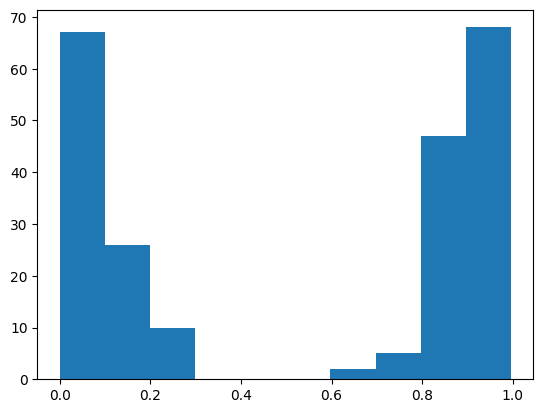

In [455]:
plt.hist(pred_y)

In [427]:
pos_idxs = np.argwhere(pred_y == 1).flatten()

In [428]:
jibar_docs[pred_y < 0.5]

link
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-2/    (creído, ver, algo, con, que, jamás, soñaron, ...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (cuando, creemos, que, nadie, había, \n, de, p...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (secunoart, io, esünwa, fsa, libe-at, que, com...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-27/ed-1/seq-3/    (Al, hacer, la, explosión, ,, un, jíbaro, que, ;)
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-29/ed-1/seq-3/    (Kpecia'ista, en, la, curación, de, \n, las, e...
                                                                                                   ...                        
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-5/    (|, \n, Girls, ,, Learm, Shorthand, ;, \n, |, ...
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-2/    (El, sol, era, un, derroche, 

In [316]:
len(responses)

167

In [429]:
len(jibar_docs)

2825

In [264]:
jibar_docs[pos_idxs]

/var/folders/nw/4k8cbbj93j9gvknkvl_w8c1c0000gq/T/ipykernel_57738/971559592.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  jibar_docs[pos_idxs]


Series([], Name: doc_cleaned, dtype: object)

In [68]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [466]:
CountVectorizer(

In [467]:
len(selected_docs)

102

In [468]:
# tfs = get_term_freqs(selected_docs.apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20)))
tfs = get_term_freqs(selected_docs)

In [469]:
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('jíbara', 59),
 ('jíbaro', 40),
 ('jibaro', 39),
 ('...', 39),
 ('fué', 28),
 ('jíbaros', 26),
 ('don', 24),
 ('san', 20),
 ('noche', 18),
 ('caballeros', 16),
 ('casa', 15),
 ('juan', 15),
 ('periódico', 13),
 ('do', 12),
 ('obra', 12),
 ('fiesta', 12),
 ('so', 11),
 ('ia', 11),
 ('ta', 11),
 ('damas', 11),
 ('colón', 11),
 ('bailes', 11),
 ('titulada', 11),
 ('campos', 11),
 ('rico', 10),
 ('cuba', 10),
 ('manuel', 10),
 ('trajes', 10),
 ('metros', 10),
 ('jibara', 10),
 ('eu', 9),
 ('corrientes', 9),
 ('celebrará', 9),
 ('consejo', 9),
 ('1543', 9),
 ('tradicional', 9),
 ('canciones', 9),
 ('obsequios', 9),
 ('apropiados', 9),
 ('ofrecerán', 9),
 ('con-', 9),
 ('currentes', 9),
 ('vestirán', 9),
 ('típicos', 9),
 ('ádeb', 9),
 ('pablo', 8),
 ('puerto', 8),
 ('ios', 8),
 ('amores', 8),
 ('sargento', 8),
 ('droz', 8),
 ('josé', 7),
 ('caballos', 7),
 ('cosa', 7),
 ('carrera', 7),
 ('cayey', 7),
 ('playa', 7),
 ('gui', 7),
 ('casado', 7),
 ('barrio', 6),
 ('fen', 6),
 ('recibe', 6),


In [ ]:
(jibar --> Gibar
